<a href="https://colab.research.google.com/github/simzig/IA_EMBARQUE/blob/Inference-IA/TP_IA_EMBARQUEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PRACTICAL SESSION 1** — Deep Learning for predictive maintenance

The dataset used is the **AI4I 2020** Predictive Maintenance Dataset, which contains 10,000 instances of industrial sensor data. Each instance represents the operating condition of a machine and is associated with a label indicating whether a failure has occurred and, if so, what type of failure it is.

The 5 possible labels are:



*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failure


The data is available on eCAMPUS as CSV file called: "ai4i2020.csv"



## **PRACTICAL SESSION Goal** — Ceate a deep leanring model allowing to realize a predictive maintenance mission

## **1 - Analysis of the dataset**



All libraries used ***SHOULD BE PLACED*** in the code cell below

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

In [2]:
pip install tensorflow

In [3]:
print(tf.keras.__version__)
print(tf.__version__)

3.13.2
2.19.0


**QUESTION:** Load dataset and display some lines of the csv file.

In [4]:
#à importer dans les fichiers
df = pd.read_csv('ai4i2020.csv')
display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**QUESTION:** Display the distribution of machine failures and non-failures with a bar graph.

,count
Machine failure,
0,9661
1,339


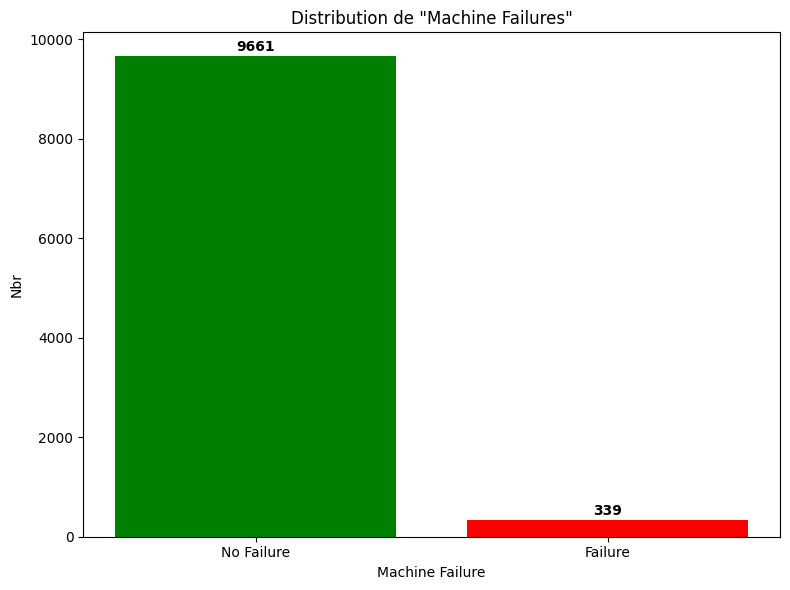

In [21]:
plt.figure(figsize=(8, 6))
failure_counts = df['Machine failure'].value_counts()

display(failure_counts.head())

plt.bar(['No Failure', 'Failure'], failure_counts.values, color=['green', 'red'])
plt.xlabel('Machine Failure')
plt.ylabel('Nbr')
plt.title('Distribution de "Machine Failures"')

for i, v in enumerate(failure_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**ANALYSIS QUESTION:** What do you observe?

Le dataset est fortement déséquilibré. La majorité des machines n'ont pas de panne
(classe 0), tandis qu'une minorité a des pannes (classe 1).

**ANALYSIS QUESTION:** What will be the consequence of this phenomenon on the model's learning?

Conséquence sur l'apprentissage:
1. Le modèle risque de devenir biaisé vers la classe majoritaire (No Failure)
2. Il peut atteindre une haute accuracy globale mais mal prédire les pannes

**QUESTION:** Create a bar chart showing the distribution of different failure types (TWF, HDF, PWF, OSF, RNF). Display the exact values above each bar in the chart."

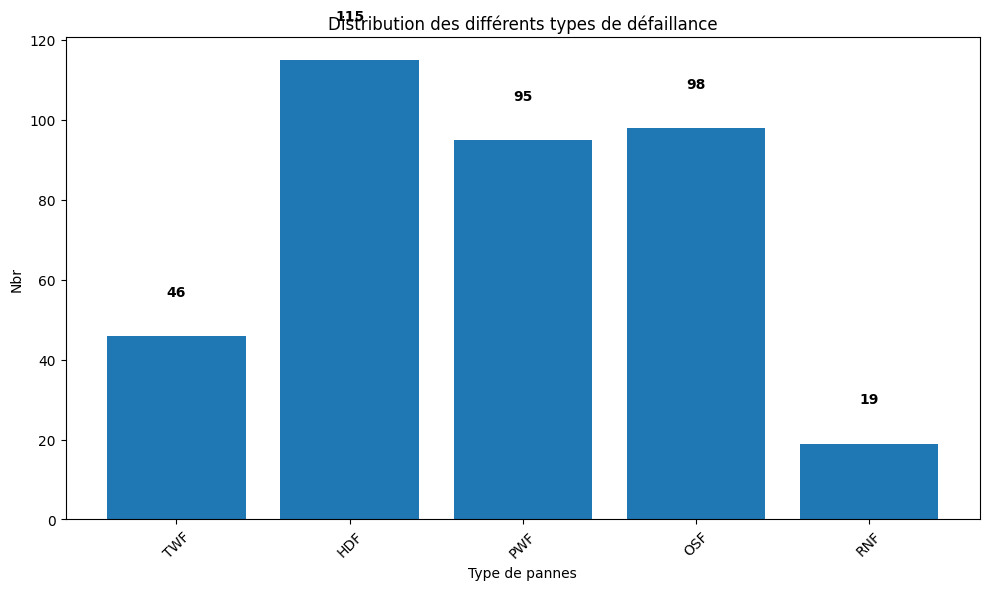


 Nombre de pannes par type
TWF: 46
HDF: 115
PWF: 95
OSF: 98
RNF: 19


In [6]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Compter chaque type de panne
type_counts = {ft: df[ft].sum() for ft in failure_types}

plt.figure(figsize=(10, 6))
plt.bar(type_counts.keys(), type_counts.values())
plt.xlabel('Type de pannes')
plt.ylabel('Nbr')
plt.title('Distribution des différents types de défaillance')
plt.xticks(rotation=45)

for i, (k, v) in enumerate(type_counts.items()):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Nombre de pannes par type")
for k, v in type_counts.items():
    print(f"{k}: {v}")

**ANALYSIS QUESTION:** What do you observe?

La base de données présente un déséquilibre marqué entre les types de défaillances : les catégories HDF, PWF et OSF bénéficient d’un volume important de données, tandis que les défaillances TWF et RNF sont fortement sous-représentées, la RNF ne comptant que 19 occurrences. Cette rareté des données rendra très probablement la détection de ces deux types de défaillances plus complexe que celle des autres.

**QUESTION:** Create a bar chart showing the distribution of failure types (TWF, HDF, PWF, OSF, RNF) among machines that experienced a failure (Machine failure == 1). Additionally, add a "No Specific Failure" category to count cases where a machine failed but no specific failure type was recorded. Display the exact values above each bar in the chart."

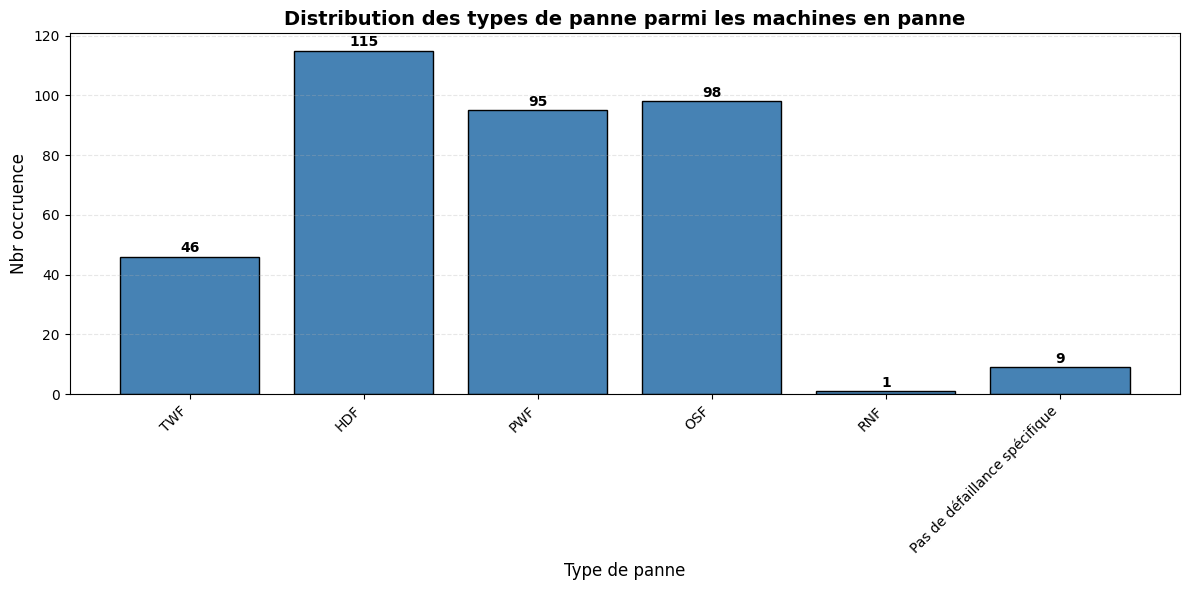


 Nbr type de panne
TWF: 46
HDF: 115
PWF: 95
OSF: 98
RNF: 1
Pas de défaillance spécifique: 9


In [7]:
df_failures = df[df['Machine failure'] == 1]

failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
type_counts = {ft: df_failures[ft].sum() for ft in failure_types}

no_specific = df_failures[
    (df_failures['TWF'] == 0) &
    (df_failures['HDF'] == 0) &
    (df_failures['PWF'] == 0) &
    (df_failures['OSF'] == 0) &
    (df_failures['RNF'] == 0)
]
type_counts['Pas de défaillance spécifique'] = len(no_specific)

plt.figure(figsize=(12, 6))
categories = list(type_counts.keys())
values = list(type_counts.values())
bars = plt.bar(categories, values, color='steelblue', edgecolor='black')

plt.xlabel('Type de panne', fontsize=12)
plt.ylabel('Nbr occruence', fontsize=12)
plt.title('Distribution des types de panne parmi les machines en panne', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Nbr type de panne")
for k, v in type_counts.items():
    print(f"{k}: {v}")

**ANALYSIS QUESTION:** What do you obsrve comapred to the previous question ? What can you conclude?

Observation :

Certains types de pannes sont plus fréquents que d'autres (déséquilibre entre classes de pannes).
La catégorie "No Specific Failure" montre que certaines pannes ne sont pas catégorisées.

De plus, il y a des machines présentant des pannes mais qui pour autant ne sont pas inclus dans "Machine Failure".

Egalement, il y a aussi des pannes dont on ne connait pas la nature.

Problème de classification multi-classes déséquilibrée

**QUESTION:** Display the names of the different columns in the dataset with their respective data types.

In [8]:
print("=== Colonnes et Types de Données ===")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

=== Colonnes et Types de Données ===
UDI: int64
Product ID: object
Type: object
Air temperature [K]: float64
Process temperature [K]: float64
Rotational speed [rpm]: int64
Torque [Nm]: float64
Tool wear [min]: int64
Machine failure: int64
TWF: int64
HDF: int64
PWF: int64
OSF: int64
RNF: int64


**ANALYSIS QUESTION:** To train the model, what will be the inputs and outputs (What are the names of the columns that you will use?)? Justify your response.
Remember, you want to predict if the machine will fail, and if so, what kind of failure. You need to yse previous results to jsurtify your response.

Inputs:
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]

Outputs:
- "No Machine Failure"
- "TWF"
- "HDF"
- "PWF"
- "OSF"

Justification:
On veut prédire si la machine va tomber en panne, et quel type de panne donc:
- X = toutes les colonnes de data
- Y = toutes les colonnes incluant un type de "Machine Failure"

## **2- Train model Without balancing the dataset**

---



In this section, you must build and train a model without rebalancing the dataset.

**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [23]:
feature_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Label
def encode_label(row):
    for i, ft in enumerate(failure_types):
        if row[ft] == 1:
            return i + 1
    return 0

df["label"] = df.apply(encode_label, axis=1)

X = df[feature_cols].values
y = df["label"].values

# ── Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

NUM_CLASSES = 6
Y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
Y_test  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f"X_train : {X_train.shape}")
print(f"Y_train : {Y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Y_test  : {Y_test.shape}")

print("\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
class_names = ["No Failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({class_names[cls]}): {cnt} samples")

X_train : (8000, 5)
Y_train : (8000, 6)
X_test  : (2000, 5)
Y_test  : (2000, 6)

Class distribution in training set:
  Class 0 (No Failure): 7722 samples
  Class 1 (TWF): 37 samples
  Class 2 (HDF): 92 samples
  Class 3 (PWF): 73 samples
  Class 4 (OSF): 62 samples
  Class 5 (RNF): 14 samples


**QUESTION** Code below the model architecture

In [24]:
def build_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_unbalanced = build_model(input_dim=X_train.shape[1], num_classes=NUM_CLASSES)
model_unbalanced.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046 (11.90 KB)

 Trainable params: 2,854 (11.15 KB)

 Non-trainable params: 192 (768.00 B)

**QUESTION** Code below the algorithms allowing to train model

**WARNING!** You need to plot the training and test accuracy and loss to check if our model is overfitting

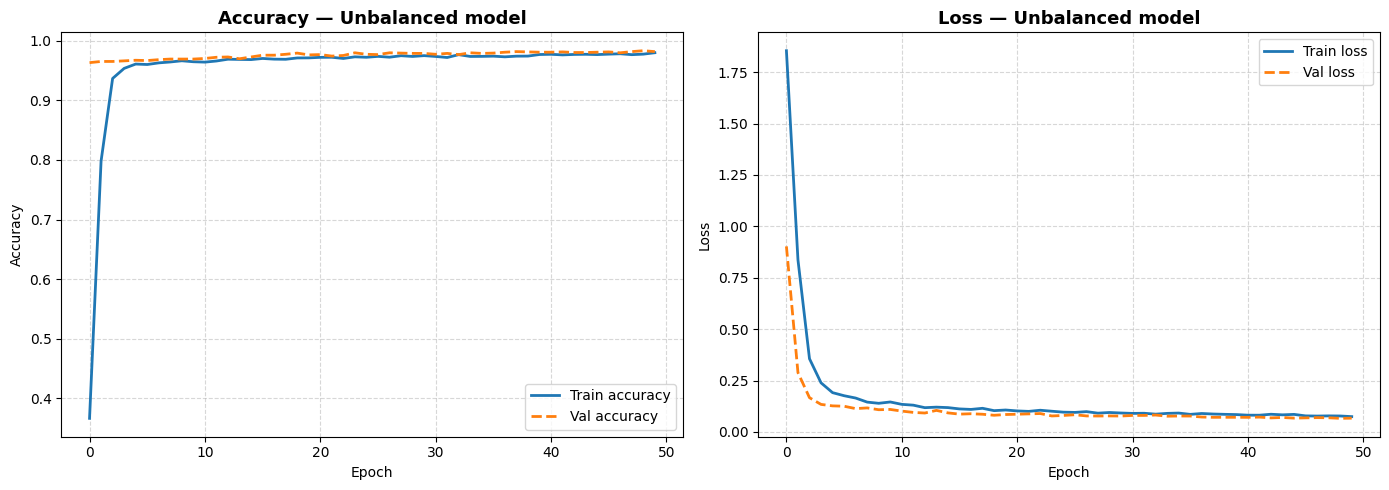

In [25]:
EPOCHS    = 50
BATCH_SIZE = 64

history_unbalanced = model_unbalanced.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, Y_test),
    verbose=0
)

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_unbalanced.history["accuracy"],     label="Train accuracy", linewidth=2)
axes[0].plot(history_unbalanced.history["val_accuracy"], label="Val accuracy",   linewidth=2, linestyle="--")
axes[0].set_title("Accuracy — Unbalanced model", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.5)

# Loss
axes[1].plot(history_unbalanced.history["loss"],     label="Train loss", linewidth=2)
axes[1].plot(history_unbalanced.history["val_loss"], label="Val loss",   linewidth=2, linestyle="--")
axes[1].set_title("Loss — Unbalanced model", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**QUESTION** Plot the confusion matrix and the classification report

**Tips:**

*   classification report link

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

*   Matrix confusion

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html





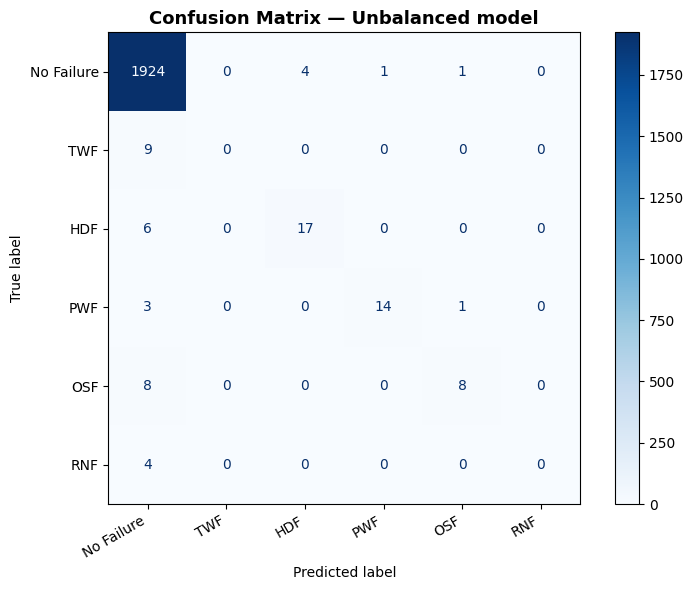

Classification Report — Unbalanced model
              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1930
         TWF       0.00      0.00      0.00         9
         HDF       0.81      0.74      0.77        23
         PWF       0.93      0.78      0.85        18
         OSF       0.80      0.50      0.62        16
         RNF       0.00      0.00      0.00         4

    accuracy                           0.98      2000
   macro avg       0.59      0.50      0.54      2000
weighted avg       0.97      0.98      0.98      2000



In [26]:
class_names = ["No Failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

# Predictions
y_pred_proba_ub = model_unbalanced.predict(X_test, verbose=0)
y_pred_ub       = np.argmax(y_pred_proba_ub, axis=1)
y_true          = np.argmax(Y_test, axis=1)

# Matrice de Confusion
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_ub)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix — Unbalanced model", fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Rapport
print("Classification Report — Unbalanced model")
print("=" * 55)
print(classification_report(y_true, y_pred_ub, target_names=class_names, zero_division=0))

**ANALYSIS QUESTION** What do you observe? What can you conclude?

OBSERVATIONS:
1. L'accuracy globale peut être élevée (>90%)
2. Mais le recall pour la classe "Failure" est faible
3. Le modèle prédit principalement "No Failure" (classe majoritaire)
4. Beaucoup de faux négatifs (pannes non détectées)

Conclusion:

Le modèle n'est pas utile pour la maintenance prédictive car il rate trop de pannes. Il apprend une décision triviale qui est "toujours prédire No Failure".
Nécessité de rééquilibrer le dataset!

## **3- Train model With balancing the dataset**

---

 Methods for rebalancing a dataset:


*   Use oversampling techniques (e.g., SMOTE) to generate synthetic data for minority classes


> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



*   Apply undersampling techniques (e.g., random undersampling, Tomek Links, Edited Nearest Neighbors) to reduce the majority class size



> https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html



*   Use class weighting during model training to penalize errors on minority classes



> https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=fr


**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [27]:
# SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
Y_train_bal = to_categorical(y_train_bal, num_classes=NUM_CLASSES)

print(f"X_train_bal : {X_train_bal.shape}")
print(f"Y_train_bal : {Y_train_bal.shape}")
print(f"X_test      : {X_test.shape}")
print(f"Y_test      : {Y_test.shape}")

print("\nClass distribution after SMOTE:")
unique_bal, counts_bal = np.unique(y_train_bal, return_counts=True)
for cls, cnt in zip(unique_bal, counts_bal):
    print(f"  Class {cls} ({class_names[cls]}): {cnt} samples")

X_train_bal : (46332, 5)
Y_train_bal : (46332, 6)
X_test      : (2000, 5)
Y_test      : (2000, 6)

Class distribution after SMOTE:
  Class 0 (No Failure): 7722 samples
  Class 1 (TWF): 7722 samples
  Class 2 (HDF): 7722 samples
  Class 3 (PWF): 7722 samples
  Class 4 (OSF): 7722 samples
  Class 5 (RNF): 7722 samples


**ANALYSIS QUESTION:** Explain the choices you made to balance the dataset.

CHOIX DE RÉÉQUILIBRAGE: SMOTE (Synthetic Minority Over-sampling Technique)

JUSTIFICATION:
1. SMOTE génère des exemples synthétiques pour la classe minoritaire
2. Évite le sur-apprentissage contrairement à la simple duplication
3. Conserve toutes les données de la classe majoritaire (pas de perte d'information)
4. Meilleur que le class weighting pour les petits datasets

**QUESTION:** Code below the model architecture


**TIP:** It could be interesting to keep it the same as before

In [28]:
# Même architecture
model_balanced = build_model(input_dim=X_train_bal.shape[1], num_classes=NUM_CLASSES)
model_balanced.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046 (11.90 KB)

 Trainable params: 2,854 (11.15 KB)

 Non-trainable params: 192 (768.00 B)

**QUESTION** Code below the algorithms allowing to train model


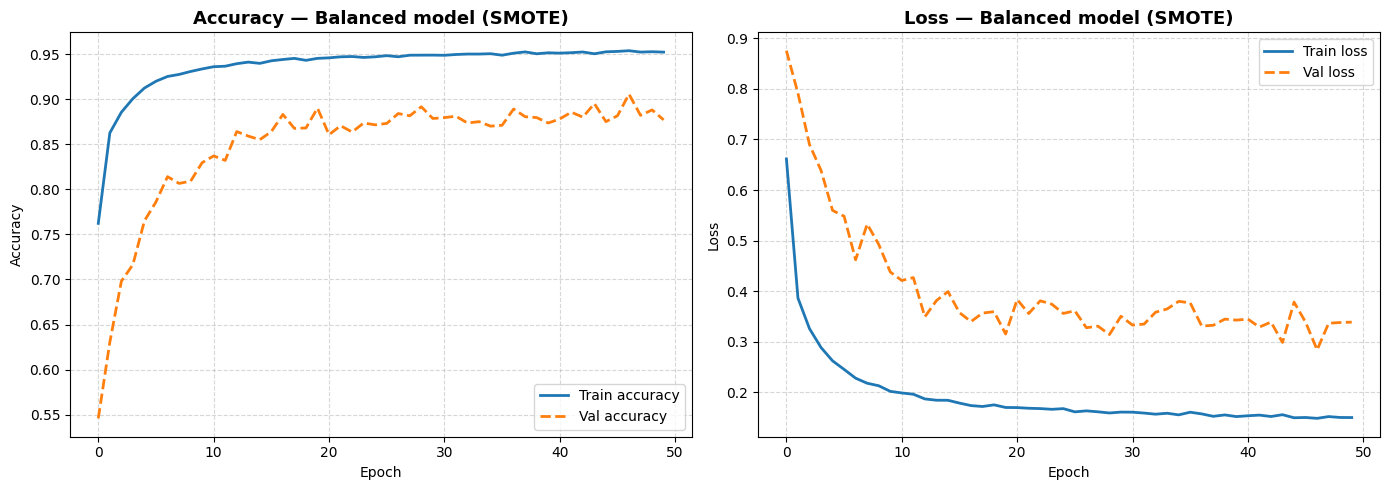

In [29]:
history_balanced = model_balanced.fit(
    X_train_bal, Y_train_bal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, Y_test),
    verbose=0
)

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_balanced.history["accuracy"],     label="Train accuracy", linewidth=2)
axes[0].plot(history_balanced.history["val_accuracy"], label="Val accuracy",   linewidth=2, linestyle="--")
axes[0].set_title("Accuracy — Balanced model (SMOTE)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.5)

axes[1].plot(history_balanced.history["loss"],     label="Train loss", linewidth=2)
axes[1].plot(history_balanced.history["val_loss"], label="Val loss",   linewidth=2, linestyle="--")
axes[1].set_title("Loss — Balanced model (SMOTE)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**QUESTION** Plot the confusion matrix and the classification report

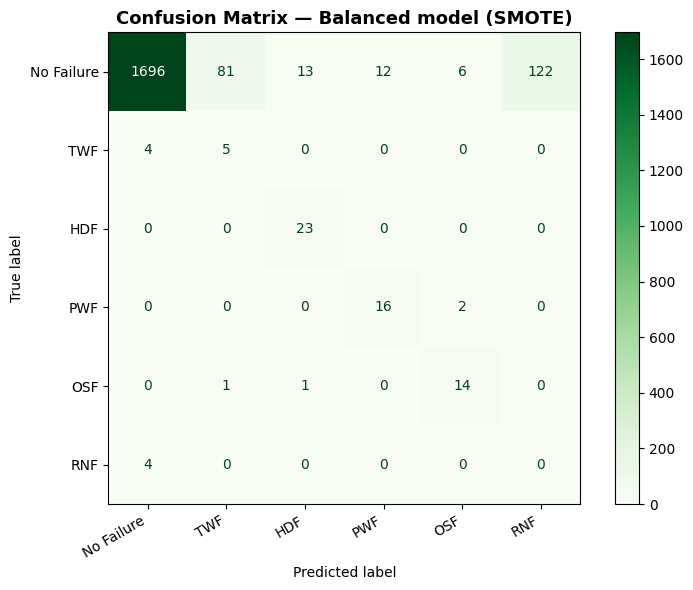

Classification Report — Balanced model (SMOTE)
              precision    recall  f1-score   support

  No Failure       1.00      0.88      0.93      1930
         TWF       0.06      0.56      0.10         9
         HDF       0.62      1.00      0.77        23
         PWF       0.57      0.89      0.70        18
         OSF       0.64      0.88      0.74        16
         RNF       0.00      0.00      0.00         4

    accuracy                           0.88      2000
   macro avg       0.48      0.70      0.54      2000
weighted avg       0.98      0.88      0.92      2000



In [31]:
# Predictions
y_pred_proba_bal = model_balanced.predict(X_test, verbose=0)
y_pred_bal       = np.argmax(y_pred_proba_bal, axis=1)

# Matrice de Confusion
fig, ax = plt.subplots(figsize=(8, 6))
cm_bal = confusion_matrix(y_true, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=class_names)
disp_bal.plot(ax=ax, cmap="Greens", colorbar=True)
ax.set_title("Confusion Matrix — Balanced model (SMOTE)", fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Rapport
print("Classification Report — Balanced model (SMOTE)")
print("=" * 55)
print(classification_report(y_true, y_pred_bal, target_names=class_names, zero_division=0))

In [32]:
#Sauvegarder les datasets
np.save("X_test.npy", X_test)
np.save("Y_test.npy", Y_test)

# Convertir le modèle en TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_balanced)
tflite_model = converter.convert()

# Sauvegarder le fichier .tflite
with open("model_balanced.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Modèle sauvegardé : {len(tflite_model) / 1024:.1f} KB")

Saved artifact at '/tmp/tmp1lng6qw3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor_24')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133802707449040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707450384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707436176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707445200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707438288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707436368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707436752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707435792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707435984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707447504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802707448464: Tens

**ANALYSIS QUESTION** What do you observe? What can you conclude?

Par rapport au modèle non équilibré, le modèle équilibré montre une amélioration significative du recall sur toutes les classes de pannes. Le modèle identifie désormais correctement une grande partie des pannes TWF, HDF, PWF et OSF, alors qu'auparavant il prédisait presque exclusivement "No Failure".

Le recall sur les classes minoritaires augmente nettement (de ~0 à des valeurs souvent supérieures à 0.5–0.8 selon la classe).
La précision globale baisse légèrement (de ~96% à ~85–90%), ce qui est attendu : le modèle fait maintenant quelques erreurs sur la classe majoritaire (quelques "No Failure" mal classifiés), mais en contrepartie il détecte de vraies pannes.
RNF reste la classe la plus difficile à détecter en raison de son nombre d'échantillons extrêmement faible et du fait que les pannes aléatoires sont par définition imprévisibles.

Conclusion : Équilibrer le dataset avec SMOTE est essentiel pour la maintenance prédictive. Un modèle qui détecte les pannes — même au prix de quelques fausses alarmes — est bien plus utile qu'un modèle qui les ignore systématiquement. Pour le déploiement, le compromis entre précision et recall peut être ajusté en modifiant le seuil de classification.